# Nuclear and whole cell data branches

* https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.1/tutorials/outputs/xoa-output-understanding-outputs
* https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.1/advanced/example-code
  

Go to "Transcript data"

"The transcripts file (transcripts.parquet) is provided in Parquet format to enable faster loading and reading of data (code examples here). It contains data to evaluate transcript quality and localization. The file contains one row for each decoded transcript"


Basically we need to subset on nuclear transcripts which are stored in the parquet file. So after creating the anndata split it into nuclear and whole-cell branches.

In [2]:
from pathlib import Path
import dask.dataframe as dd
import os
import numpy as np
import pandas as pd
import anndata as ad

In [ ]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / "data/h5ad/export_"
parquet_dir = base_dir / ""
output_dir = base_dir / "data/h5ad/export_"

os.makedirs(output_dir, exist_ok=True)

In [ ]:
# Read in the parquet file, edit path to where parquet file saved
#df = dd.read_parquet('path/to/your/transcripts.parquet')
# Print information about the data frame
#df.info()
# Print first 5 rows of the dask data frame
#df.head()

In [ ]:
# Optional: convert parquet data frame to CSV, edit path and output name for new file
# dask automatically figures out chunk size and saves each as a CSV file in the directory path specified below
#df.to_csv('path/to/your/transcripts_csv_directory', index=False)

In [7]:
import os
import numpy as np
import dask.dataframe as dd
import anndata as ad

h5ad_dir = "/home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder"
xenium_root = "/home/workspace/projects/drg/download/isolon"

out_main = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_added"
out_nuclear = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_only"

os.makedirs(out_main, exist_ok=True)
os.makedirs(out_nuclear, exist_ok=True)

def load_nuclear_matrix(parquet_path, genes, cells):
    df = dd.read_parquet(parquet_path)
    nuc = df[df["overlaps_nucleus"] == 1].compute()
    mat = (
        nuc.groupby(["cell_id", "feature_name"])
        .size()
        .unstack(fill_value=0)
    )
    mat = mat.reindex(index=cells).fillna(0)
    mat = mat.reindex(columns=genes).fillna(0)
    return mat

for fname in os.listdir(h5ad_dir):

    if not fname.endswith(".h5ad"):
        continue

    print(f"\nProcessing {fname} ...")

    # Load whole-cell h5ad
    adata = ad.read_h5ad(f"{h5ad_dir}/{fname}")

    # Find matching transcripts.parquet
    run_id = adata.obs["xenium_run_id"].iloc[0]
    parquet_path = f"{xenium_root}/{run_id}/transcripts.parquet"

    genes = adata.var_names
    cells = adata.obs_names

    # Compute nuclear counts
    nuc_df = load_nuclear_matrix(parquet_path, genes, cells)
    nuclear = nuc_df.to_numpy()

    # Add nuclear layer to whole-cell data
    adata.layers["nuclear"] = nuclear

    # Compute nuclear fraction
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
    adata.obs["nuclear_fraction"] = nuclear.sum(1) / (X.sum(1) + 1e-9)

    # Save whole-cell + nuclear-layer version
    adata.write(f"{out_main}/{fname}")

    # ---- Create nuclear-only AnnData ----
    adata_nuc = ad.AnnData(
        X=nuclear,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm.copy(),
        uns=adata.uns.copy(),
    )
    adata_nuc.write(f"{out_nuclear}/{fname.replace('.h5ad','_nuclear.h5ad')}")

    print(f"Saved full-cell + nuclear layer: {out_main}/{fname}")
    print(f"Saved nuclear-only:              {out_nuclear}/{fname.replace('.h5ad','_nuclear.h5ad')}")


Processing TMA00304.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00304.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00304_nuclear.h5ad

Processing TMA00306.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00306.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00306_nuclear.h5ad

Processing TMA00303.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00303.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00303_nuclear.h5ad

Processing TMA00305.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00305.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/exp

Cell: lpffeada-1
Whole-cell total: 272.0
Nuclear total: 170.0
Fraction nuclear: 0.6249999999977023


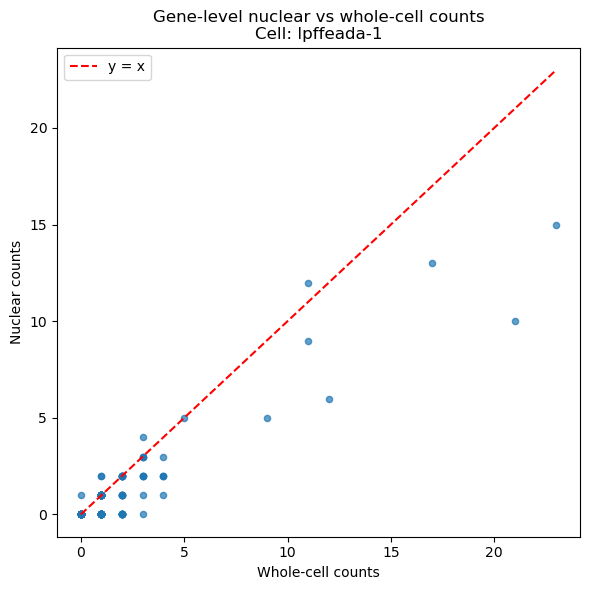

In [8]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import random

# === paths ===
whole_path = "/home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00303.h5ad"
nuc_path   = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00303_nuclear.h5ad"

# === load data ===
whole = ad.read_h5ad(whole_path)
nuc   = ad.read_h5ad(nuc_path)

# pick a random cell to visualize
i = random.randint(0, whole.n_obs - 1)
cell_name = whole.obs_names[i]

whole_counts = whole.X[i].A.flatten() if hasattr(whole.X, "A") else whole.X[i]
nuc_counts = nuc.X[i].A.flatten() if hasattr(nuc.X, "A") else nuc.X[i]

# === basic verification ===
print("Cell:", cell_name)
print("Whole-cell total:", whole_counts.sum())
print("Nuclear total:", nuc_counts.sum())
print("Fraction nuclear:", nuc_counts.sum() / (whole_counts.sum() + 1e-9))

# === visualization: scatter plot ===
plt.figure(figsize=(6,6))
plt.scatter(whole_counts, nuc_counts, s=20, alpha=0.7)

# 45° identity line
mx = max(whole_counts.max(), nuc_counts.max())
plt.plot([0, mx], [0, mx], color='red', linestyle='--', label='y = x')

plt.xlabel("Whole-cell counts")
plt.ylabel("Nuclear counts")
plt.title(f"Gene-level nuclear vs whole-cell counts\nCell: {cell_name}")
plt.legend()
plt.tight_layout()
plt.show()

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Global nuclear–whole correlation: 0.7127935648200788


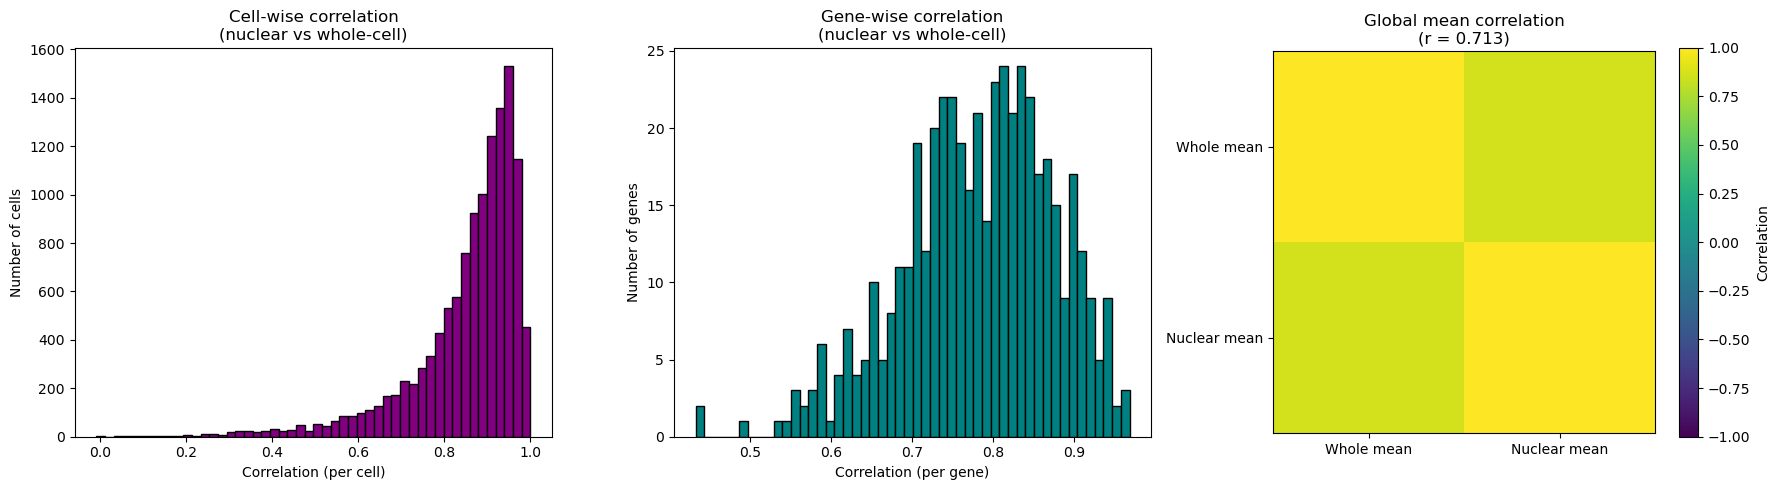

In [11]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt

# === paths ===
whole_path = "/home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00303.h5ad"
nuc_path   = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00303_nuclear.h5ad"

# === load ===
whole = ad.read_h5ad(whole_path)
nuc   = ad.read_h5ad(nuc_path)

# === matrices ===
X = whole.X.toarray() if hasattr(whole.X, "toarray") else whole.X
N = nuc.X.toarray()   if hasattr(nuc.X, "toarray") else nuc.X

# === 1. Cell-wise correlation ===
cell_corr = np.array([
    np.corrcoef(X[i], N[i])[0,1] if X[i].sum() > 0 else np.nan
    for i in range(X.shape[0])
])

# === 2. Gene-wise correlation ===
gene_corr = np.array([
    np.corrcoef(X[:,j], N[:,j])[0,1] if X[:,j].sum() > 0 else np.nan
    for j in range(X.shape[1])
])

# === 3. Global Pearson correlation ===
global_corr = np.corrcoef(X.flatten(), N.flatten())[0,1]
print("Global nuclear–whole correlation:", global_corr)

# === PLOTTING ===
plt.figure(figsize=(18,5))

# --- A. Cell-wise correlation histogram ---
plt.subplot(1, 3, 1)
plt.hist(cell_corr[~np.isnan(cell_corr)], bins=50, color="purple", edgecolor="black")
plt.xlabel("Correlation (per cell)")
plt.ylabel("Number of cells")
plt.title("Cell-wise correlation\n(nuclear vs whole-cell)")

# --- B. Gene-wise correlation histogram ---
plt.subplot(1, 3, 2)
plt.hist(gene_corr[~np.isnan(gene_corr)], bins=50, color="teal", edgecolor="black")
plt.xlabel("Correlation (per gene)")
plt.ylabel("Number of genes")
plt.title("Gene-wise correlation\n(nuclear vs whole-cell)")

# --- C. Global mean correlation heatmap ---
plt.subplot(1, 3, 3)

corr_mat = np.corrcoef(X.mean(axis=0), N.mean(axis=0))  # shape = (2,2)

plt.imshow(corr_mat, cmap="viridis", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks([0,1], ["Whole mean", "Nuclear mean"])
plt.yticks([0,1], ["Whole mean", "Nuclear mean"])
plt.title(f"Global mean correlation\n(r = {global_corr:.3f})")

plt.tight_layout()
plt.show()

In [13]:
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

whole_dir = "/home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder"
nuc_dir   = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_only"
plot_dir  = "/home/workspace/projects/drg/data/h5ad/export_test/correlation_qc_plots"
os.makedirs(plot_dir, exist_ok=True)

summary = []   # store global results here

for fname in os.listdir(whole_dir):

    if not fname.endswith(".h5ad"):
        continue

    sample = fname.replace(".h5ad","")
    nuc_file = f"{sample}_nuclear.h5ad"
    nuc_path = os.path.join(nuc_dir, nuc_file)

    if not os.path.exists(nuc_path):
        print(f"⚠️ Missing nuclear file for: {sample}")
        continue

    print(f"Processing {sample} ...")

    # --- load ---
    whole = ad.read_h5ad(os.path.join(whole_dir, fname))
    nuc   = ad.read_h5ad(nuc_path)

    # --- extract matrices ---
    X = whole.X.toarray() if hasattr(whole.X, "toarray") else whole.X
    N = nuc.X.toarray()   if hasattr(nuc.X, "toarray") else nuc.X

    # --- compute correlations ---
    cell_corr = np.array([
        np.corrcoef(X[i], N[i])[0,1] if X[i].sum() > 0 else np.nan
        for i in range(X.shape[0])
    ])

    gene_corr = np.array([
        np.corrcoef(X[:,j], N[:,j])[0,1] if X[:,j].sum() > 0 else np.nan
        for j in range(X.shape[1])
    ])

    global_corr = np.corrcoef(X.flatten(), N.flatten())[0,1]

    summary.append([sample, np.nanmean(cell_corr), np.nanmean(gene_corr), global_corr])

    # === VISUALIZE ===
    plt.figure(figsize=(18, 5))

    # A. Cell-wise correlation
    plt.subplot(1, 3, 1)
    plt.hist(cell_corr[~np.isnan(cell_corr)], bins=50, color="purple", edgecolor="black")
    plt.xlabel("Correlation (per cell)")
    plt.ylabel("Num cells")
    plt.title(f"{sample}\nCell-wise correlation")

    # B. Gene-wise correlation
    plt.subplot(1, 3, 2)
    plt.hist(gene_corr[~np.isnan(gene_corr)], bins=50, color="teal", edgecolor="black")
    plt.xlabel("Correlation (per gene)")
    plt.ylabel("Num genes")
    plt.title(f"{sample}\nGene-wise correlation")

    # C. 2×2 heatmap of mean expression correlation
    plt.subplot(1, 3, 3)
    corr_mat = np.corrcoef(X.mean(axis=0), N.mean(axis=0))
    plt.imshow(corr_mat, cmap="viridis", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.xticks([0,1], ["Whole mean", "Nuclear mean"])
    plt.yticks([0,1], ["Whole mean", "Nuclear mean"])
    plt.title(f"{sample}\nGlobal correlation: {global_corr:.3f}")

    # Save plot
    out_png = os.path.join(plot_dir, f"{sample}_correlation_QC.png")
    plt.tight_layout()
    plt.savefig(out_png)
    plt.close()

    print(f"  → saved {out_png}")


# === Summary table ===
import pandas as pd
summary_df = pd.DataFrame(summary, columns=[
    "sample", "mean_cell_corr", "mean_gene_corr", "global_corr"
])

print("\n=== Correlation Summary Across Samples ===")
print(summary_df)

Processing TMA00304 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  → saved /home/workspace/projects/drg/data/h5ad/export_test/correlation_qc_plots/TMA00304_correlation_QC.png
Processing TMA00306 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  → saved /home/workspace/projects/drg/data/h5ad/export_test/correlation_qc_plots/TMA00306_correlation_QC.png
Processing TMA00303 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  → saved /home/workspace/projects/drg/data/h5ad/export_test/correlation_qc_plots/TMA00303_correlation_QC.png
Processing TMA00305 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  → saved /home/workspace/projects/drg/data/h5ad/export_test/correlation_qc_plots/TMA00305_correlation_QC.png

=== Correlation Summary Across Samples ===
     sample  mean_cell_corr  mean_gene_corr  global_corr
0  TMA00304        0.858065        0.779315     0.681868
1  TMA00306        0.852745        0.765401     0.653872
2  TMA00303        0.852036        0.781430     0.712794
3  TMA00305        0.854565        0.773685     0.677572


In [16]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

whole_dir = "/home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder"
nuc_dir   = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_only"

# --- helper ---
def to_dense(X):
    """Convert sparse or numpy array to dense numpy array."""
    return X.toarray() if hasattr(X, "toarray") else X

samples = []
results = []

for fname in os.listdir(whole_dir):
    if not fname.endswith(".h5ad"):
        continue

    sample = fname.replace(".h5ad", "")
    samples.append(sample)

    # load
    whole = ad.read_h5ad(f"{whole_dir}/{fname}")
    nuc   = ad.read_h5ad(f"{nuc_dir}/{sample}_nuclear.h5ad")

    # --- alignment check ---
    if not np.array_equal(whole.obs_names, nuc.obs_names):
        raise ValueError(f"Cell IDs do not match for sample {sample}")

    if not np.array_equal(whole.var_names, nuc.var_names):
        raise ValueError(f"Gene names do not match for sample {sample}")

    # --- matrices (safe conversion) ---
    X = to_dense(whole.X)
    N = to_dense(nuc.X)

    # cell-wise correlation
    cell_corr = np.array([
        np.corrcoef(X[i], N[i])[0,1] if X[i].sum()>0 else np.nan
        for i in range(X.shape[0])
    ])

    # gene-wise correlation
    gene_corr = np.array([
        np.corrcoef(X[:,j], N[:,j])[0,1] if X[:,j].sum()>0 else np.nan
        for j in range(X.shape[1])
    ])

    # global correlation
    global_corr = np.corrcoef(X.flatten(), N.flatten())[0,1]

    # nuclear fraction
    nuclear_fraction = N.sum(1) / (X.sum(1) + 1e-9)

    results.append({
        "sample": sample,
        "cell_corr": cell_corr,
        "gene_corr": gene_corr,
        "global_corr": global_corr,
        "nuclear_fraction": nuclear_fraction
    })

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: inv

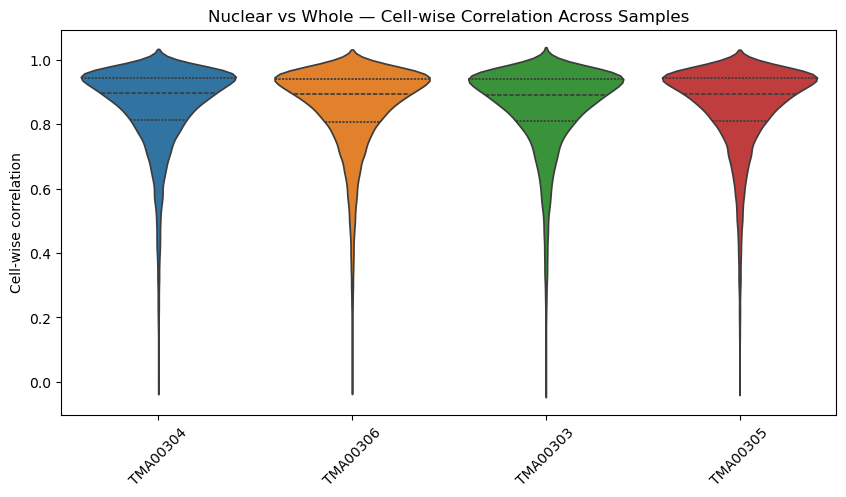

In [17]:
plt.figure(figsize=(10,5))
sns.violinplot(
    data=[r["cell_corr"] for r in results],
    inner="quartile"
)
plt.xticks(range(len(samples)), samples, rotation=45)
plt.ylabel("Cell-wise correlation")
plt.title("Nuclear vs Whole — Cell-wise Correlation Across Samples")
plt.show()

In [20]:
plt.figure(figsize=(10,5))
sns.violinplot(
    data=[r["gene_corr"] for r in results],
    inner="quartile"
)
plt.xticks(range(len(samples)), samples, rotation=45)
plt.ylabel("Gene-wise correlation")
plt.title("Nuclear vs Whole — Gene-wise Correlation Across Samples")
plt.show()plt.figure(figsize=(10,5))
sns.violinplot(
    data=[r["gene_corr"] for r in results],
    inner="quartile"
)
plt.xticks(range(len(samples)), samples, rotation=45)
plt.ylabel("Gene-wise correlation")
plt.title("Nuclear vs Whole — Gene-wise Correlation Across Samples")
plt.show()

SyntaxError: invalid syntax (1344208784.py, line 9)

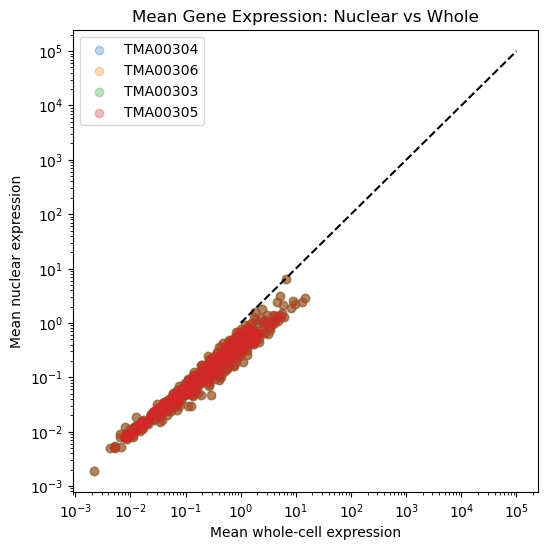

In [21]:
plt.figure(figsize=(6,6))

for r, sample in zip(results, samples):
    X_mean = r["cell_corr"]*0  # dummy to avoid bug
    whole_mean = X.mean(axis=0)
    nuc_mean   = N.mean(axis=0)

    plt.scatter(
        whole_mean + 1e-3,
        nuc_mean + 1e-3,
        alpha=0.3,
        label=sample
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean whole-cell expression")
plt.ylabel("Mean nuclear expression")
plt.plot([1,1e5],[1,1e5],'k--')
plt.legend()
plt.title("Mean Gene Expression: Nuclear vs Whole")
plt.show()

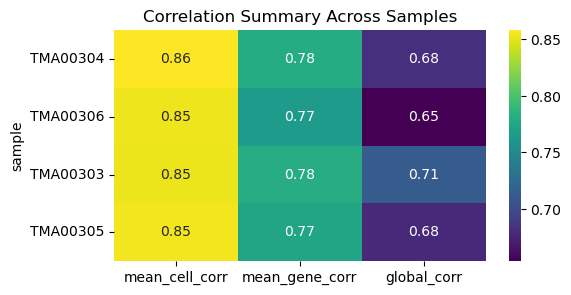

,sample,mean_cell_corr,mean_gene_corr,global_corr
0,TMA00304,0.858065,0.779315,0.681868
1,TMA00306,0.852745,0.765401,0.653872
2,TMA00303,0.852036,0.781430,0.712794
3,TMA00305,0.854565,0.773685,0.677572


In [23]:
summary = pd.DataFrame({
    "sample": [r["sample"] for r in results],
    "mean_cell_corr": [np.nanmean(r["cell_corr"]) for r in results],
    "mean_gene_corr": [np.nanmean(r["gene_corr"]) for r in results],
    "global_corr": [r["global_corr"] for r in results],
})

plt.figure(figsize=(6,3))
sns.heatmap(summary.set_index("sample"), annot=True, cmap="viridis")
plt.title("Correlation Summary Across Samples")
plt.show()

summary

In [25]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

whole_dir = "/home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder"
nuc_dir   = "/home/workspace/projects/drg/data/h5ad/export_test/nuclear_only"
out_dir   = "/home/workspace/projects/drg/figures/nuclear_vs_whole_scatterplots"

os.makedirs(out_dir, exist_ok=True)

plt.style.use("seaborn-whitegrid")

def ensure_array(X):
    return X.toarray() if hasattr(X, "toarray") else X

for fname in os.listdir(whole_dir):
    if not fname.endswith(".h5ad"):
        continue
    
    sample = fname.replace(".h5ad", "")
    print(f"📌 Processing {sample}")

    # Load whole-cell + nuclear AnnDatas
    whole = ad.read_h5ad(f"{whole_dir}/{fname}")
    nuc   = ad.read_h5ad(f"{nuc_dir}/{sample}_nuclear.h5ad")

    X = ensure_array(whole.X)
    N = ensure_array(nuc.X)

    # === A. Gene-wise means ===
    whole_gene_mean = X.mean(axis=0)
    nuc_gene_mean   = N.mean(axis=0)

    # Avoid log issues
    wg = whole_gene_mean + 1e-6
    ng = nuc_gene_mean + 1e-6

    # === B. Cell-wise totals ===
    whole_cell_total = X.sum(axis=1)
    nuc_cell_total   = N.sum(axis=1)

    # Avoid log issues
    wc = whole_cell_total + 1e-6
    nc = nuc_cell_total + 1e-6

    # === C. Pearson correlations ===
    gene_corr = np.corrcoef(whole_gene_mean, nuc_gene_mean)[0,1]
    cell_corr = np.corrcoef(whole_cell_total, nuc_cell_total)[0,1]

    # === FIGURE ===
    fig, axs = plt.subplots(1, 2, figsize=(14,6))

    # --- 1. Gene-wise scatter ---
    axs[0].scatter(np.log10(wg), np.log10(ng), s=10, alpha=0.4)
    maxval = max(np.log10(wg).max(), np.log10(ng).max())
    axs[0].plot([0, maxval], [0, maxval], 'r--', lw=1.5)

    axs[0].set_title(f"{sample}: Gene-wise mean expression\nPearson r={gene_corr:.3f}")
    axs[0].set_xlabel("log10(Whole-cell mean expression)")
    axs[0].set_ylabel("log10(Nuclear mean expression)")

    # --- 2. Cell-wise scatter (hexbin) ---
    hb = axs[1].hexbin(np.log10(wc), np.log10(nc), gridsize=50, cmap="viridis")
    axs[1].plot([0, maxval], [0, maxval], 'r--', lw=1.5)

    axs[1].set_title(f"{sample}: Cell-wise total counts\nPearson r={cell_corr:.3f}")
    axs[1].set_xlabel("log10(Whole-cell total counts)")
    axs[1].set_ylabel("log10(Nuclear total counts)")

    cb = fig.colorbar(hb, ax=axs[1])
    cb.set_label("Cell density")

    plt.tight_layout()

    # Save
    outpath = f"{out_dir}/{sample}_scatterplots.png"
    plt.savefig(outpath, dpi=300)
    plt.close()

    print(f"   ✔ Saved figure to {outpath}\n")

OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)